# Задание 2. Методы линейной регрессии и их сравнение

#### 1. Загрузка датасета и вывод на экран

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score

# Загрузка датасета
data = pd.read_csv('auto_dataset.csv')
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


#### 2. Разбиение датасета на train, val, test в соотношении 8:1:1

In [46]:
X = data.drop('price', axis=1)
y = data['price']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print('Train:', X_train.shape, y_train.shape)
print('Val:  ', X_val.shape, y_val.shape)
print('Test: ', X_test.shape, y_test.shape)

Train: (800, 9) (800,)
Val:   (100, 9) (100,)
Test:  (100, 9) (100,)


#### Вывод первых строк каждой выборки на экран

In [47]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

train_view = pd.concat([X_train, y_train], axis=1)
val_view   = pd.concat([X_val, y_val], axis=1)
test_view  = pd.concat([X_test, y_test], axis=1)

print("TRAIN:")
print(train_view.head(), "\n")

print("VALIDATION:")
print(val_view.head(), "\n")

print("TEST:")
print(test_view.head())

TRAIN:
             brand     model vehicleType    gearbox fuelType  \
29            audi        a8   limousine  automatik   diesel   
535     volkswagen      golf   limousine    manuell   benzin   
695           ford    fiesta  kleinwagen    manuell   benzin   
557  mercedes_benz  c_klasse   limousine    manuell   benzin   
836     volkswagen      golf   limousine    manuell   benzin   

    notRepairedDamage  powerPS  kilometer  autoAgeMonths  price  
29                 ja      232     150000            145   7499  
535              nein       75     125000            248   1099  
695              nein      101      40000             17  12800  
557              nein      163     100000            190   4200  
836              nein      122     150000             96   6199   

VALIDATION:
          brand        model vehicleType    gearbox fuelType  \
411  volkswagen         golf   limousine  automatik   diesel   
621     renault         clio  kleinwagen    manuell   benzin   
721  v

#### 2. Кодирование категориальных признаков для всех выборок

Это необходимо сделать, чтобы перевести все словесные характеристики в числа для будущего обучения.

In [48]:
cat_cols = ['brand', 'model', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']
num_cols = ['powerPS', 'kilometer', 'autoAgeMonths']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc   = preprocessor.transform(X_val)
X_test_enc  = preprocessor.transform(X_test)

print("Train:", X_train_enc.shape)
print("Val:  ", X_val_enc.shape)
print("Test: ", X_test_enc.shape)


Train: (800, 194)
Val:   (100, 194)
Test:  (100, 194)


In [49]:
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)


#### 3. Исследование VanillaGradientDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите VanillaGradientDescent с шагом lyamda на train, вычисляем R^2_train и Loss_train;

протестируйте VanillaGradientDescent с шагом lyamda на val, вычисляем Loss_val.

2. Найдите наилучший шаг lyamda по минимальному Loss_val.

In [50]:
class VanillaGradientDescent:
    def __init__(self, learning_rate=0.01, n_iters=3000, tol=1e-8, verbose=False):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.tol = tol
        self.verbose = verbose
        self.w = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        y = np.asarray(y, dtype=float)
        self.loss_history = []

        for i in range(self.n_iters):
            y_pred = np.asarray(X @ self.w).ravel()
            error = y_pred - y
            grad = (2.0 / n_samples) * np.asarray(X.T @ error).ravel()

            self.w -= self.learning_rate * grad

            loss = float(np.mean(error ** 2))
            self.loss_history.append(loss)

            if not np.isfinite(loss):
                self.loss_history.append(np.inf)
                break

            if np.linalg.norm(grad) < self.tol:
                break

        return self

    def predict(self, X):
        return np.asarray(X @ self.w).ravel()

    def score(self, X, y):
        y = np.asarray(y, dtype=float)
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1.0 - ss_res / ss_tot

In [51]:
lambdas = np.logspace(-5, 0, 11)

results = []

for lam in lambdas:
    model = VanillaGradientDescent(learning_rate=lam, n_iters=3000, tol=1e-8)
    model.fit(X_train_enc, y_train_log)

    y_train_pred = model.predict(X_train_enc)
    if np.all(np.isfinite(y_train_pred)):
        loss_train = float(np.mean((y_train_log - y_train_pred) ** 2))
        r2_train   = r2_score(y_train_log, y_train_pred)
    else:
        loss_train, r2_train = np.inf, np.nan

    y_val_pred = model.predict(X_val_enc)
    if np.all(np.isfinite(y_val_pred)):
        loss_val = float(np.mean((y_val_log - y_val_pred) ** 2))
        r2_val   = r2_score(y_val_log, y_val_pred)
    else:
        loss_val, r2_val = np.inf, np.nan

    results.append({
        'lambda':     lam,
        'Loss_train': loss_train,
        'R2_train':   r2_train,
        'Loss_val':   loss_val,
        'R2_val':     r2_val,
        'iters':      len(model.loss_history),
    })

results_df = pd.DataFrame(results)
pd.set_option('display.float_format', lambda x: f'{x:.6g}')
print(results_df.to_string(index=False))

     lambda  Loss_train  R2_train  Loss_val     R2_val  iters
      1e-05     53.2247  -38.4452   55.0597   -51.5503   3000
3.16228e-05     29.6924  -21.0052   31.4373   -29.0044   3000
     0.0001     5.85617  -3.34005   6.56441   -5.26523   3000
0.000316228     1.24449 0.0776998   1.13651 -0.0847112   3000
      0.001    0.745659  0.447387  0.606354   0.421281   3000
 0.00316228    0.495363  0.632882  0.351374   0.664641   3000
       0.01    0.416251  0.691513  0.279957   0.732802   3000
  0.0316228    0.369419  0.726221  0.273027   0.739417   3000
        0.1    0.336516  0.750605  0.326811   0.688084   3000
   0.316228    0.323241  0.760443  0.378844   0.638423   3000
          1         inf      -inf       inf       -inf    261


/usr/lib/python3.14/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/usr/lib/python3.14/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/lib/python3.14/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [52]:
best_row    = results_df.loc[results_df['Loss_val'].idxmin()]
best_lambda = best_row['lambda']
print(f"Лучший шаг (lambda) = {best_lambda:.6g}")

best_model = VanillaGradientDescent(learning_rate=best_lambda, n_iters=3000, tol=1e-8)
best_model.fit(X_train_enc, y_train_log)

# train
y_train_pred = best_model.predict(X_train_enc)
loss_train = float(np.mean((y_train_log - y_train_pred) ** 2))
r2_train   = r2_score(y_train_log, y_train_pred)

# test
y_test_pred = best_model.predict(X_test_enc)
loss_test = float(np.mean((y_test_log - y_test_pred) ** 2))
r2_test   = r2_score(y_test_log, y_test_pred)

n_iter_vanilla = len(best_model.loss_history)


Лучший шаг (lambda) = 0.0316228


#### 4. Тестирование VanillaGradientDescent с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [53]:

print(f"R2_test   = {r2_test:.4f}")
print(f"Loss_test  = {loss_test:.6f}")


R2_test   = 0.5745
Loss_test  = 0.709214


#### 5. Вывод по VanillaGradientDescent

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

In [54]:
best_row    = results_df.loc[results_df['Loss_val'].idxmin()]
best_lambda = best_row['lambda']
print(f"Лучший шаг (lambda) = {best_lambda:.6g}")

best_model = VanillaGradientDescent(learning_rate=best_lambda, n_iters=3000, tol=1e-8)
best_model.fit(X_train_enc, y_train_log)

# train
y_train_pred = best_model.predict(X_train_enc)
loss_train = float(np.mean((y_train_log - y_train_pred) ** 2))
r2_train   = r2_score(y_train_log, y_train_pred)

# test
y_test_pred = best_model.predict(X_test_enc)
loss_test = float(np.mean((y_test_log - y_test_pred) ** 2))
r2_test   = r2_score(y_test_log, y_test_pred)

n_iter_vanilla = len(best_model.loss_history)

print(f"Loss_train = {loss_train:.6f}")
print(f"Loss_test  = {loss_test:.6f}")
print(f"R2_train   = {r2_train:.4f}")
print(f"Итераций   = {n_iter_vanilla}")

Лучший шаг (lambda) = 0.0316228
Loss_train = 0.369419
Loss_test  = 0.709214
R2_train   = 0.7262
Итераций   = 3000


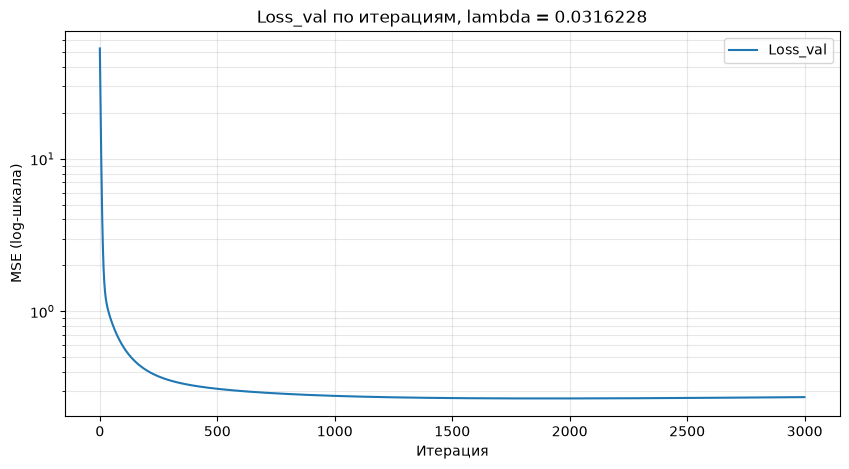

In [55]:
n_iters = 3000
lam     = best_lambda

w = np.zeros(X_train_enc.shape[1])
loss_val_hist = []

y_train_arr = np.asarray(y_train_log, dtype=float)
y_val_arr   = np.asarray(y_val_log,   dtype=float)
n_samples   = X_train_enc.shape[0]

for i in range(n_iters):
    err = np.asarray(X_train_enc @ w).ravel() - y_train_arr
    grad = (2.0 / n_samples) * np.asarray(X_train_enc.T @ err).ravel()
    w -= lam * grad

    loss_val_hist.append(
        float(np.mean((y_val_arr - np.asarray(X_val_enc @ w).ravel()) ** 2))
    )

plt.figure(figsize=(10, 5))
plt.plot(loss_val_hist, label='Loss_val', linewidth=1.5)
plt.xlabel('Итерация')
plt.ylabel('MSE (log-шкала)')
plt.title(f'Loss_val по итерациям, lambda = {lam:.6g}')
plt.yscale('log')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

#### 6. Исследование StochasticGradientDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите StochasticGradientDescent с шагом lyamda на train, вычислите R_train ^ 2 и Loss_train;

протестируйте StochasticGradientDescent с шагом lyamda на val, вычислите Loss_val.

2. Найдите лучший шаг lyamda по минимальному Loss_val.

In [56]:
class StochasticGradientDescent:
    def __init__(self, learning_rate=0.01, n_iters=50, tol=1e-8,
                 random_state=42, verbose=False):
        self.learning_rate = learning_rate
        self.n_iters = n_iters      
        self.tol = tol
        self.random_state = random_state
        self.verbose = verbose
        self.w = None
        self.loss_history = []

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        y = np.asarray(y, dtype=float)
        self.loss_history = []

        is_sparse = hasattr(X, "toarray")

        for epoch in range(self.n_iters):
            indices = rng.permutation(n_samples)

            for i in indices:
                x_i = X[i]
                if is_sparse:
                    x_i = np.asarray(x_i.toarray()).ravel()
                else:
                    x_i = np.asarray(x_i, dtype=float).ravel()

                err = float(x_i @ self.w - y[i])
                grad = 2.0 * err * x_i
                self.w -= self.learning_rate * grad

                if not np.all(np.isfinite(self.w)):
                    self.loss_history.append(np.inf)
                    return self

            y_pred = np.asarray(X @ self.w).ravel()
            loss = float(np.mean((y - y_pred) ** 2))
            self.loss_history.append(loss)

            if not np.isfinite(loss):
                self.loss_history.append(np.inf)
                break

        return self

    def predict(self, X):
        return np.asarray(X @ self.w).ravel()

    def score(self, X, y):
        y = np.asarray(y, dtype=float)
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1.0 - ss_res / ss_tot

In [57]:
results_sgd = []

for lam in lambdas:
    model = StochasticGradientDescent(learning_rate=lam, n_iters=50,
                                      tol=1e-8, random_state=42)
    model.fit(X_train_enc, y_train_log)

    y_train_pred = model.predict(X_train_enc)
    if np.all(np.isfinite(y_train_pred)):
        loss_train = float(np.mean((y_train_log - y_train_pred) ** 2))
        r2_train   = r2_score(y_train_log, y_train_pred)
    else:
        loss_train, r2_train = np.inf, np.nan

    y_val_pred = model.predict(X_val_enc)
    if np.all(np.isfinite(y_val_pred)):
        loss_val = float(np.mean((y_val_log - y_val_pred) ** 2))
        r2_val   = r2_score(y_val_log, y_val_pred)
    else:
        loss_val, r2_val = np.inf, np.nan

    results_sgd.append({
        'lambda':     lam,
        'Loss_train': loss_train,
        'R2_train':   r2_train,
        'Loss_val':   loss_val,
        'R2_val':     r2_val,
        'epochs':     len(model.loss_history),
    })

results_sgd_df = pd.DataFrame(results_sgd)
print(results_sgd_df.to_string(index=False))

     lambda  Loss_train     R2_train    Loss_val       R2_val  epochs
      1e-05       3.297     -1.44343     3.66599     -2.49891      50
3.16228e-05     1.09631     0.187514    0.969864    0.0743389      50
     0.0001    0.655978      0.51385    0.515493     0.508002      50
0.000316228    0.468947      0.65246    0.326823     0.688072      50
      0.001    0.402952      0.70137    0.278582     0.734114      50
 0.00316228    0.363616     0.730522    0.287171     0.725917      50
       0.01    0.365688     0.728986    0.328199     0.686759      50
  0.0316228    0.607991     0.549413    0.449718     0.570778      50
        0.1 1.26454e+64 -9.37158e+63 1.27182e+64 -1.21385e+64      50
   0.316228         inf         -inf         inf         -inf       3
          1         inf          NaN         inf          NaN       1


/tmp/ipykernel_6016/1288391460.py:40: RuntimeWarning: overflow encountered in square
  loss = float(np.mean((y - y_pred) ** 2))
/usr/lib/python3.14/site-packages/sklearn/metrics/_regression.py:1304: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)
/usr/lib/python3.14/site-packages/sklearn/metrics/_regression.py:1304: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)
/tmp/ipykernel_6016/1288391460.py:32: RuntimeWarning: invalid value encountered in multiply
  grad = 2.0 * err * x_i


In [58]:
best_row_sgd    = results_sgd_df.loc[results_sgd_df['Loss_val'].idxmin()]
best_lambda_sgd = best_row_sgd['lambda']
print(f"Лучший шаг (lambda) SGD = {best_lambda_sgd:.6g}")

best_sgd = StochasticGradientDescent(learning_rate=best_lambda_sgd,
                                     n_iters=50, tol=1e-8, random_state=42)
best_sgd.fit(X_train_enc, y_train_log)

y_train_pred_sgd = best_sgd.predict(X_train_enc)
loss_train_sgd = float(np.mean((y_train_log - y_train_pred_sgd) ** 2))
r2_train_sgd   = r2_score(y_train_log, y_train_pred_sgd)

y_test_pred_sgd = best_sgd.predict(X_test_enc)
loss_test_sgd = float(np.mean((y_test_log - y_test_pred_sgd) ** 2))
r2_test_sgd   = r2_score(y_test_log, y_test_pred_sgd)

n_iter_sgd = len(best_sgd.loss_history)


Лучший шаг (lambda) SGD = 0.001


#### 7. Тестирование StochasticGradientDescent с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [59]:
print(f"R2_test   = {r2_test_sgd:.4f}")
print(f"Loss_test = {loss_test_sgd:.6f}")

R2_test   = 0.5584
Loss_test = 0.736004


#### 8. Вывод по StochasticGradientDescent

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

In [60]:
print(f"Лучший шаг (lambda) SGD = {best_lambda_sgd:.6g}")
print(f"Loss_train = {loss_train_sgd:.6f}")
print(f"Loss_test  = {loss_test_sgd:.6f}")
print(f"R2_train   = {r2_train_sgd:.4f}")
print(f"Эпох       = {n_iter_sgd}")

Лучший шаг (lambda) SGD = 0.001
Loss_train = 0.402952
Loss_test  = 0.736004
R2_train   = 0.7014
Эпох       = 50


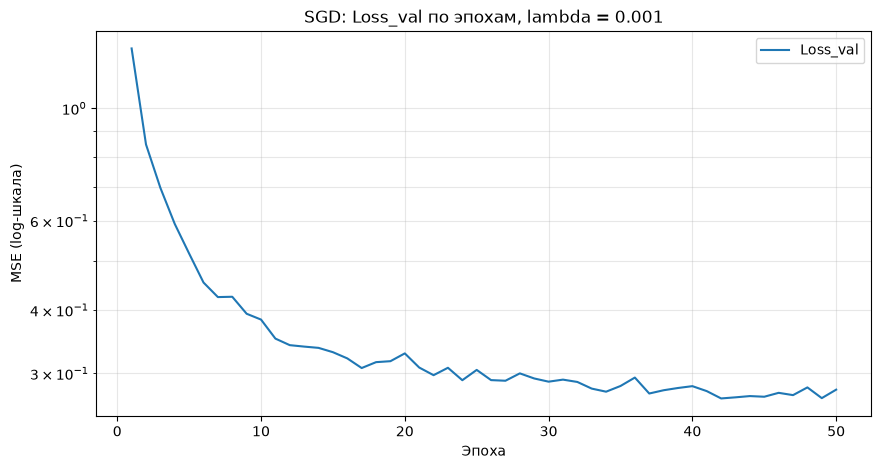

In [61]:
n_epochs = 50
lam = best_lambda_sgd

rng = np.random.default_rng(42)
n_samples, n_features = X_train_enc.shape
w = np.zeros(n_features)

y_train_arr = np.asarray(y_train_log, dtype=float)
y_val_arr   = np.asarray(y_val_log,   dtype=float)

is_sparse = hasattr(X_train_enc, "toarray")
loss_val_hist_sgd = []

for epoch in range(n_epochs):
    indices = rng.permutation(n_samples)
    for i in indices:
        x_i = X_train_enc[i]
        if is_sparse:
            x_i = np.asarray(x_i.toarray()).ravel()
        else:
            x_i = np.asarray(x_i, dtype=float).ravel()
        err = float(x_i @ w - y_train_arr[i])
        grad = 2.0 * err * x_i
        w -= lam * grad

    loss_val_hist_sgd.append(
        float(np.mean((y_val_arr - np.asarray(X_val_enc @ w).ravel()) ** 2))
    )

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), loss_val_hist_sgd, label='Loss_val', linewidth=1.5)
plt.xlabel('Эпоха')
plt.ylabel('MSE (log-шкала)')
plt.title(f'SGD: Loss_val по эпохам, lambda = {lam:.6g}')
plt.yscale('log')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

#### 9. Исследование SAGDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите SAGDescent с шагом lyamda на train, вычисляем R^2_train и Loss_train;

протестируйте SAGDescent с шагом lyamda на val, вычисляем Loss_val.

2. Найдите наилучший шаг lyamda по минимальному Loss_val.

In [62]:
class SAGDescent:
    def __init__(self, learning_rate=0.01, n_iters=50, random_state=42, verbose=False):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.verbose = verbose
        self.w = None
        self.loss_history = []

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n_samples, n_features = X.shape
        y = np.asarray(y, dtype=float)
        self.w = np.zeros(n_features)
        self.loss_history = []

        is_sparse = hasattr(X, "toarray")

        grad_memory = np.zeros((n_samples, n_features))
        grad_sum = np.zeros(n_features)

        for epoch in range(self.n_iters):
            indices = rng.permutation(n_samples)

            for i in indices:
                x_i = X[i]
                if is_sparse:
                    x_i = np.asarray(x_i.toarray()).ravel()
                else:
                    x_i = np.asarray(x_i, dtype=float).ravel()

                err = float(x_i @ self.w - y[i])
                new_grad = 2.0 * err * x_i

                grad_sum += new_grad - grad_memory[i]
                grad_memory[i] = new_grad

                avg_grad = grad_sum / n_samples
                self.w -= self.learning_rate * avg_grad

            y_pred = np.asarray(X @ self.w).ravel()
            loss = float(np.mean((y - y_pred) ** 2))
            self.loss_history.append(loss)

            if not np.isfinite(loss):
                self.loss_history.append(np.inf)
                return self

        return self

    def predict(self, X):
        return np.asarray(X @ self.w).ravel()

    def score(self, X, y):
        y = np.asarray(y, dtype=float)
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1.0 - ss_res / ss_tot

In [63]:
results_sag = []

for lam in lambdas:
    model = SAGDescent(learning_rate=lam, n_iters=50, random_state=42)
    model.fit(X_train_enc, y_train_log)

    y_train_pred = model.predict(X_train_enc)
    if np.all(np.isfinite(y_train_pred)):
        loss_train = float(np.mean((y_train_log - y_train_pred) ** 2))
        r2_train   = r2_score(y_train_log, y_train_pred)
    else:
        loss_train, r2_train = np.inf, np.nan

    y_val_pred = model.predict(X_val_enc)
    if np.all(np.isfinite(y_val_pred)):
        loss_val = float(np.mean((y_val_log - y_val_pred) ** 2))
        r2_val   = r2_score(y_val_log, y_val_pred)
    else:
        loss_val, r2_val = np.inf, np.nan

    results_sag.append({
        'lambda':     lam,
        'Loss_train': loss_train,
        'R2_train':   r2_train,
        'Loss_val':   loss_val,
        'R2_val':     r2_val,
        'epochs':     len(model.loss_history),
    })

results_sag_df = pd.DataFrame(results_sag)
print(results_sag_df.to_string(index=False))

     lambda   Loss_train      R2_train     Loss_val        R2_val  epochs
      1e-05      3.23157      -1.39494      3.59107       -2.4274      50
3.16228e-05      1.09752      0.186616     0.971279     0.0729885      50
     0.0001     0.656502      0.513462     0.516186       0.50734      50
0.000316228     0.469079      0.652362     0.325838      0.689012      50
      0.001     0.401751      0.702259     0.274658       0.73786      50
 0.00316228  3.99351e+13  -2.95962e+13  3.37166e+13  -3.21799e+13      50
       0.01  1.83123e+08  -1.35714e+08  1.23845e+08    -1.182e+08      50
  0.0316228  2.73345e+15  -2.02578e+15   2.7375e+15  -2.61274e+15      50
        0.1  4.53482e+25  -3.36079e+25   4.5378e+25  -4.33099e+25      50
   0.316228  2.34086e+71  -1.73483e+71  1.83401e+71  -1.75042e+71      50
          1 3.83192e+186 -2.83987e+186 3.75152e+186 -3.58054e+186      50


In [64]:
best_row_sag    = results_sag_df.loc[results_sag_df['Loss_val'].idxmin()]
best_lambda_sag = best_row_sag['lambda']
print(f"Лучший шаг (lambda) SAG = {best_lambda_sag:.6g}")

best_sag = SAGDescent(learning_rate=best_lambda_sag, n_iters=50, random_state=42)
best_sag.fit(X_train_enc, y_train_log)

y_train_pred_sag = best_sag.predict(X_train_enc)
loss_train_sag = float(np.mean((y_train_log - y_train_pred_sag) ** 2))
r2_train_sag   = r2_score(y_train_log, y_train_pred_sag)

y_test_pred_sag = best_sag.predict(X_test_enc)
loss_test_sag = float(np.mean((y_test_log - y_test_pred_sag) ** 2))
r2_test_sag   = r2_score(y_test_log, y_test_pred_sag)

n_iter_sag = len(best_sag.loss_history)

print(f"Loss_train = {loss_train_sag:.6f}")
print(f"R2_train   = {r2_train_sag:.4f}")
print(f"Loss_test  = {loss_test_sag:.6f}")
print(f"Эпох       = {n_iter_sag}")

Лучший шаг (lambda) SAG = 0.001
Loss_train = 0.401751
R2_train   = 0.7023
Loss_test  = 0.733909
Эпох       = 50


#### 10. Тестирование SAGDescent с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [65]:
print(f"R2_train   = {r2_train_sag:.4f}")
print(f"Loss_test  = {loss_train_sag:.6f}")

R2_train   = 0.7023
Loss_test  = 0.401751


#### 11. Вывод по SAGDescent

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

In [66]:
print(f"Лучший шаг (lambda) SAG = {best_lambda_sag:.6g}")
print(f"Loss_train = {loss_train_sag:.6f}")
print(f"Loss_test  = {loss_test_sag:.6f}")
print(f"R2_train   = {r2_train_sag:.4f}")
print(f"Эпох       = {n_iter_sag}")

Лучший шаг (lambda) SAG = 0.001
Loss_train = 0.401751
Loss_test  = 0.733909
R2_train   = 0.7023
Эпох       = 50


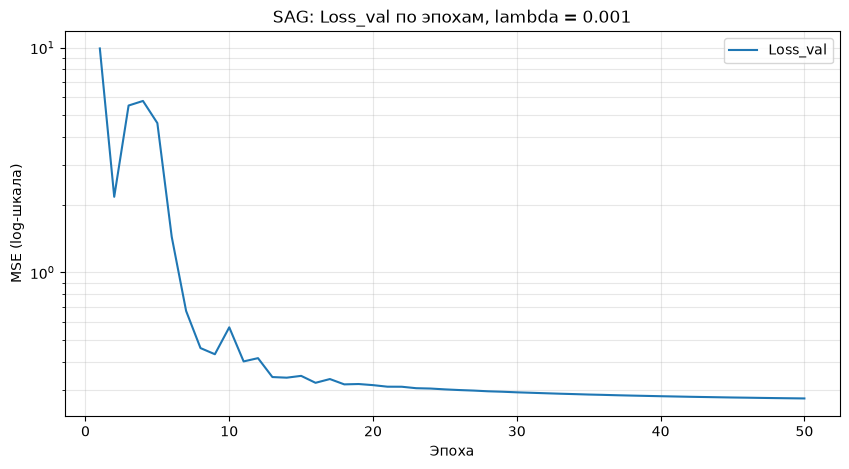

In [67]:
n_epochs = 50
lam = best_lambda_sag

rng = np.random.default_rng(42)
n_samples, n_features = X_train_enc.shape
w = np.zeros(n_features)
grad_memory = np.zeros((n_samples, n_features))
grad_sum = np.zeros(n_features)

y_train_arr = np.asarray(y_train_log, dtype=float)
y_val_arr   = np.asarray(y_val_log,   dtype=float)

is_sparse = hasattr(X_train_enc, "toarray")
loss_val_hist_sag = []

for epoch in range(n_epochs):
    indices = rng.permutation(n_samples)
    for i in indices:
        x_i = X_train_enc[i]
        if is_sparse:
            x_i = np.asarray(x_i.toarray()).ravel()
        else:
            x_i = np.asarray(x_i, dtype=float).ravel()

        err = float(x_i @ w - y_train_arr[i])
        new_grad = 2.0 * err * x_i

        grad_sum += new_grad - grad_memory[i]
        grad_memory[i] = new_grad

        w -= lam * (grad_sum / n_samples)

    loss_val_hist_sag.append(
        float(np.mean((y_val_arr - np.asarray(X_val_enc @ w).ravel()) ** 2))
    )

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), loss_val_hist_sag, label='Loss_val', linewidth=1.5)
plt.xlabel('Эпоха')
plt.ylabel('MSE (log-шкала)')
plt.title(f'SAG: Loss_val по эпохам, lambda = {lam:.6g}')
plt.yscale('log')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

#### 12. Исследование MomentumDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите MomentumDescent с шагом lyamda на train, вычисляем R^2_train и Loss_train;

протестируйте MomentumDescent с шагом lyamda на val, вычисляем Loss_val.

2. Найдите наилучший шаг lyamda по минимальному Loss_val.

In [68]:
class MomentumDescent:
    def __init__(self, learning_rate=0.01, beta=0.9, n_iters=3000,
                 tol=1e-8, random_state=42, verbose=False):
        self.learning_rate = learning_rate
        self.beta = beta
        self.n_iters = n_iters
        self.tol = tol
        self.random_state = random_state
        self.verbose = verbose
        self.w = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y = np.asarray(y, dtype=float)
        self.w = np.zeros(n_features)
        v = np.zeros(n_features)
        self.loss_history = []

        for i in range(self.n_iters):
            y_pred = np.asarray(X @ self.w).ravel()
            error = y_pred - y
            grad = (2.0 / n_samples) * np.asarray(X.T @ error).ravel()

            v = self.beta * v - self.learning_rate * grad
            self.w += v

            loss = float(np.mean(error ** 2))
            self.loss_history.append(loss)

            if not np.isfinite(loss):
                self.loss_history.append(np.inf)
                break

            if np.linalg.norm(grad) < self.tol:
                break

        return self

    def predict(self, X):
        return np.asarray(X @ self.w).ravel()

    def score(self, X, y):
        y = np.asarray(y, dtype=float)
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1.0 - ss_res / ss_tot

In [69]:
results_mom = []

for lam in lambdas:
    model = MomentumDescent(learning_rate=lam, beta=0.9, n_iters=3000,
                            tol=1e-8, random_state=42)
    model.fit(X_train_enc, y_train_log)

    y_train_pred = model.predict(X_train_enc)
    if np.all(np.isfinite(y_train_pred)):
        loss_train = float(np.mean((y_train_log - y_train_pred) ** 2))
        r2_train   = r2_score(y_train_log, y_train_pred)
    else:
        loss_train, r2_train = np.inf, np.nan

    y_val_pred = model.predict(X_val_enc)
    if np.all(np.isfinite(y_val_pred)):
        loss_val = float(np.mean((y_val_log - y_val_pred) ** 2))
        r2_val   = r2_score(y_val_log, y_val_pred)
    else:
        loss_val, r2_val = np.inf, np.nan

    results_mom.append({
        'lambda':     lam,
        'Loss_train': loss_train,
        'R2_train':   r2_train,
        'Loss_val':   loss_val,
        'R2_val':     r2_val,
        'iters':      len(model.loss_history),
    })

results_mom_df = pd.DataFrame(results_mom)
print(results_mom_df.to_string(index=False))

     lambda  Loss_train  R2_train  Loss_val     R2_val  iters
      1e-05     5.84352  -3.33068   6.55111   -5.25253   3000
3.16228e-05     1.24405  0.078028   1.13514 -0.0833997   3000
     0.0001    0.745875  0.447226   0.60661   0.421038   3000
0.000316228     0.49533  0.632907  0.351302   0.664709   3000
      0.001    0.416296   0.69148  0.279924   0.732834   3000
 0.00316228    0.369461   0.72619  0.272955   0.739485   3000
       0.01     0.33652  0.750602  0.326891   0.688007   3000
  0.0316228     0.32324  0.760444  0.378931    0.63834   3000
        0.1    0.319745  0.763035  0.399409   0.618795   3000
   0.316228    0.319361  0.763319  0.404704   0.613741   3000
          1         inf      -inf       inf       -inf    365


/usr/lib/python3.14/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/usr/lib/python3.14/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/lib/python3.14/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [70]:
best_row_mom    = results_mom_df.loc[results_mom_df['Loss_val'].idxmin()]
best_lambda_mom = best_row_mom['lambda']
print(f"Лучший шаг (lambda) Momentum = {best_lambda_mom:.6g}")

best_mom = MomentumDescent(learning_rate=best_lambda_mom, beta=0.9,
                           n_iters=3000, tol=1e-8, random_state=42)
best_mom.fit(X_train_enc, y_train_log)

y_train_pred_mom = best_mom.predict(X_train_enc)
loss_train_mom = float(np.mean((y_train_log - y_train_pred_mom) ** 2))
r2_train_mom   = r2_score(y_train_log, y_train_pred_mom)

y_test_pred_mom = best_mom.predict(X_test_enc)
loss_test_mom = float(np.mean((y_test_log - y_test_pred_mom) ** 2))
r2_test_mom   = r2_score(y_test_log, y_test_pred_mom)

n_iter_mom = len(best_mom.loss_history)



Лучший шаг (lambda) Momentum = 0.00316228


#### 13. Тестирование MomentumDescent с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [71]:
print(f"R2_test   = {r2_test_mom:.4f}")
print(f"Loss_test  = {loss_test_mom:.6f}")

R2_test   = 0.5745
Loss_test  = 0.709265


#### 14. Вывод по MomentumDescent

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

In [72]:
print(f"Лучший шаг (lambda) Momentum = {best_lambda_mom:.6g}")
print(f"Loss_train = {loss_train_mom:.6f}")
print(f"Loss_test  = {loss_test_mom:.6f}")
print(f"R2_train   = {r2_train_mom:.4f}")
print(f"Итераций   = {n_iter_mom}")

Лучший шаг (lambda) Momentum = 0.00316228
Loss_train = 0.369461
Loss_test  = 0.709265
R2_train   = 0.7262
Итераций   = 3000


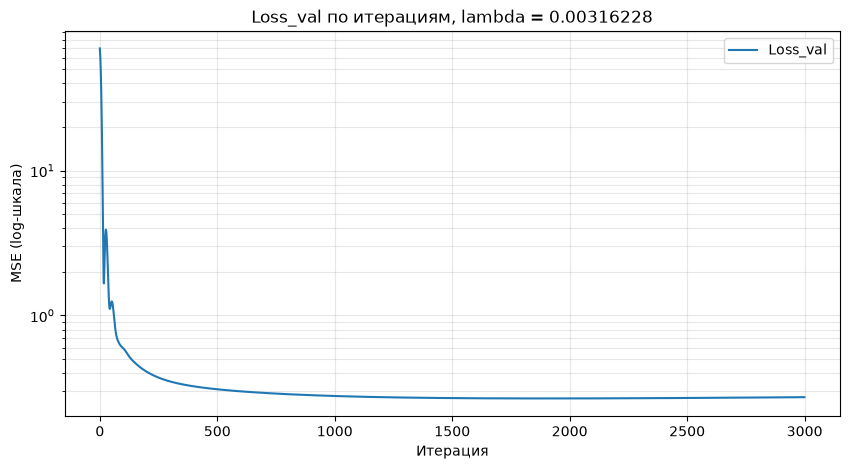

In [73]:
n_iters = 3000
lam  = best_lambda_mom
beta = 0.9

n_samples, n_features = X_train_enc.shape
w = np.zeros(n_features)
v = np.zeros(n_features)

y_train_arr = np.asarray(y_train_log, dtype=float)
y_val_arr   = np.asarray(y_val_log,   dtype=float)

loss_val_hist_mom = []

for i in range(n_iters):
    err = np.asarray(X_train_enc @ w).ravel() - y_train_arr
    grad = (2.0 / n_samples) * np.asarray(X_train_enc.T @ err).ravel()

    v = beta * v - lam * grad
    w += v

    loss_val_hist_mom.append(
        float(np.mean((y_val_arr - np.asarray(X_val_enc @ w).ravel()) ** 2))
    )

plt.figure(figsize=(10, 5))
plt.plot(loss_val_hist_mom, label='Loss_val', linewidth=1.5)
plt.xlabel('Итерация')
plt.ylabel('MSE (log-шкала)')
plt.title(f'Loss_val по итерациям, lambda = {lam:.6g}')
plt.yscale('log')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

#### 15. Исследование Adam

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите Adam с шагом lyamda на train, вычисляем R^2_train и Loss_train;

протестируйте Adam с шагом lyamda на val, вычисляем Loss_val.

2. Найдите наилучший шаг lyamda по минимальному Loss_val.

In [74]:
class Adam:
    def __init__(self, learning_rate=0.01, beta1=0.9, beta2=0.999,
                 eps=1e-8, n_iters=3000, tol=1e-8,
                 random_state=42, verbose=False):
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.n_iters = n_iters
        self.tol = tol
        self.random_state = random_state
        self.verbose = verbose
        self.w = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y = np.asarray(y, dtype=float)
        self.w = np.zeros(n_features)
        m = np.zeros(n_features)
        v = np.zeros(n_features)
        self.loss_history = []

        for t in range(1, self.n_iters + 1):
            y_pred = np.asarray(X @ self.w).ravel()
            error = y_pred - y
            grad = (2.0 / n_samples) * np.asarray(X.T @ error).ravel()

            m = self.beta1 * m + (1.0 - self.beta1) * grad
            v = self.beta2 * v + (1.0 - self.beta2) * (grad ** 2)

            m_hat = m / (1.0 - self.beta1 ** t)
            v_hat = v / (1.0 - self.beta2 ** t)

            self.w -= self.learning_rate * m_hat / (np.sqrt(v_hat) + self.eps)

            loss = float(np.mean(error ** 2))
            self.loss_history.append(loss)

            if not np.isfinite(loss):
                self.loss_history.append(np.inf)
                break

            if np.linalg.norm(grad) < self.tol:
                break

        return self

    def predict(self, X):
        return np.asarray(X @ self.w).ravel()

    def score(self, X, y):
        y = np.asarray(y, dtype=float)
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1.0 - ss_res / ss_tot

In [75]:
results_adam = []

for lam in lambdas:
    model = Adam(learning_rate=lam, beta1=0.9, beta2=0.999, eps=1e-8,
                 n_iters=3000, tol=1e-8, random_state=42)
    model.fit(X_train_enc, y_train_log)

    y_train_pred = model.predict(X_train_enc)
    if np.all(np.isfinite(y_train_pred)):
        loss_train = float(np.mean((y_train_log - y_train_pred) ** 2))
        r2_train   = r2_score(y_train_log, y_train_pred)
    else:
        loss_train, r2_train = np.inf, np.nan

    y_val_pred = model.predict(X_val_enc)
    if np.all(np.isfinite(y_val_pred)):
        loss_val = float(np.mean((y_val_log - y_val_pred) ** 2))
        r2_val   = r2_score(y_val_log, y_val_pred)
    else:
        loss_val, r2_val = np.inf, np.nan

    results_adam.append({
        'lambda':     lam,
        'Loss_train': loss_train,
        'R2_train':   r2_train,
        'Loss_val':   loss_val,
        'R2_val':     r2_val,
        'iters':      len(model.loss_history),
    })

results_adam_df = pd.DataFrame(results_adam)
print(results_adam_df.to_string(index=False))

     lambda  Loss_train  R2_train  Loss_val   R2_val  iters
      1e-05     67.0788  -48.7126   68.7256 -64.5933   3000
3.16228e-05     60.8197   -44.074   62.3884 -58.5449   3000
     0.0001      43.793  -31.4554   45.1132  -42.057   3000
0.000316228     12.3085  -8.12191   13.0223 -11.4288   3000
      0.001    0.395818  0.706656  0.465239 0.555966   3000
 0.00316228    0.329657  0.755689  0.500611 0.522205   3000
       0.01    0.322891  0.760703  0.542439 0.482284   3000
  0.0316228    0.319491  0.763223  0.561007 0.464562   3000
        0.1    0.319359  0.763321  0.563948 0.461755   3000
   0.316228    0.319359  0.763321  0.564791  0.46095   1742
          1    0.319359  0.763321  0.566052 0.459747    853


In [76]:
best_row_adam    = results_adam_df.loc[results_adam_df['Loss_val'].idxmin()]
best_lambda_adam = best_row_adam['lambda']
print(f"Лучший шаг (lambda) Adam = {best_lambda_adam:.6g}")

best_adam = Adam(learning_rate=best_lambda_adam, beta1=0.9, beta2=0.999,
                 eps=1e-8, n_iters=3000, tol=1e-8, random_state=42)
best_adam.fit(X_train_enc, y_train_log)

y_train_pred_adam = best_adam.predict(X_train_enc)
loss_train_adam = float(np.mean((y_train_log - y_train_pred_adam) ** 2))
r2_train_adam   = r2_score(y_train_log, y_train_pred_adam)

y_test_pred_adam = best_adam.predict(X_test_enc)
loss_test_adam = float(np.mean((y_test_log - y_test_pred_adam) ** 2))
r2_test_adam   = r2_score(y_test_log, y_test_pred_adam)

n_iter_adam = len(best_adam.loss_history)

print(f"Loss_train = {loss_train_adam:.6f}")
print(f"R2_train   = {r2_train_adam:.4f}")
print(f"Loss_test  = {loss_test_adam:.6f}")
print(f"Итераций   = {n_iter_adam}")

Лучший шаг (lambda) Adam = 0.001
Loss_train = 0.395818
R2_train   = 0.7067
Loss_test  = 0.909089
Итераций   = 3000


#### 16. Тестирование Adam с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [77]:
print(f"Loss_train = {loss_test_adam:.6f}")
print(f"R2_train   = {r2_test_adam:.4f}")

Loss_train = 0.909089
R2_train   = 0.4546


#### 17. Вывод по Adam

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

In [78]:
print(f"Лучший шаг (lambda) Adam = {best_lambda_adam:.6g}")
print(f"Loss_train = {loss_train_adam:.6f}")
print(f"Loss_test  = {loss_test_adam:.6f}")
print(f"R2_train   = {r2_train_adam:.4f}")
print(f"Итераций   = {n_iter_adam}")

Лучший шаг (lambda) Adam = 0.001
Loss_train = 0.395818
Loss_test  = 0.909089
R2_train   = 0.7067
Итераций   = 3000


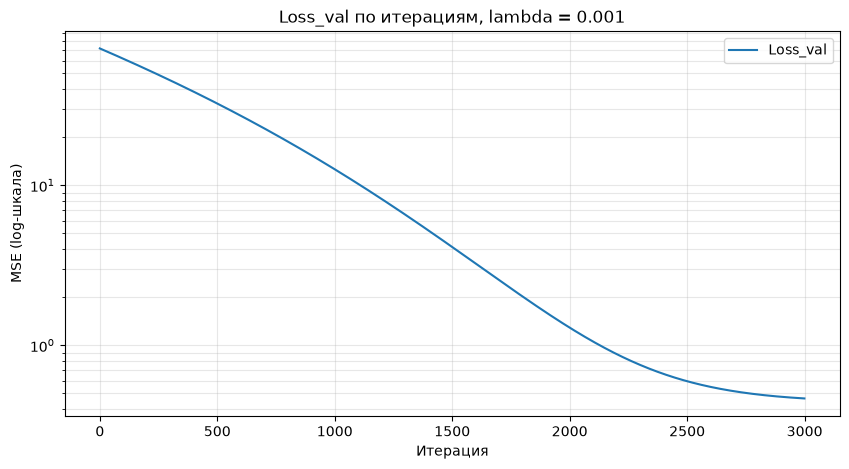

In [79]:
n_iters = 3000
lam   = best_lambda_adam
beta1 = 0.9
beta2 = 0.999
eps   = 1e-8

n_samples, n_features = X_train_enc.shape
w = np.zeros(n_features)
m = np.zeros(n_features)
v = np.zeros(n_features)

y_train_arr = np.asarray(y_train_log, dtype=float)
y_val_arr   = np.asarray(y_val_log,   dtype=float)

loss_val_hist_adam = []

for t in range(1, n_iters + 1):
    err = np.asarray(X_train_enc @ w).ravel() - y_train_arr
    grad = (2.0 / n_samples) * np.asarray(X_train_enc.T @ err).ravel()

    m = beta1 * m + (1.0 - beta1) * grad
    v = beta2 * v + (1.0 - beta2) * (grad ** 2)

    m_hat = m / (1.0 - beta1 ** t)
    v_hat = v / (1.0 - beta2 ** t)

    w -= lam * m_hat / (np.sqrt(v_hat) + eps)

    loss_val_hist_adam.append(
        float(np.mean((y_val_arr - np.asarray(X_val_enc @ w).ravel()) ** 2))
    )

plt.figure(figsize=(10, 5))
plt.plot(loss_val_hist_adam, label='Loss_val', linewidth=1.5)
plt.xlabel('Итерация')
plt.ylabel('MSE (log-шкала)')
plt.title(f'Loss_val по итерациям, lambda = {lam:.6g}')
plt.yscale('log')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

#### 18. Постройте сравнительную таблицу методов

Таблица показана в лекции (таб. 2)

In [80]:
comparison = pd.DataFrame({
    'Метод':       ['Vanilla GD', 'SGD', 'SAG', 'Momentum', 'Adam'],
    'λ*':          [best_lambda,
                    best_lambda_sgd,
                    best_lambda_sag,
                    best_lambda_mom,
                    best_lambda_adam],
    'Loss train':  [loss_train,
                    loss_train_sgd,
                    loss_train_sag,
                    loss_train_mom,
                    loss_train_adam],
    'Loss test':   [loss_test,
                    loss_test_sgd,
                    loss_test_sag,
                    loss_test_mom,
                    loss_test_adam],
    'R²_train':    [r2_train,
                    r2_train_sgd,
                    r2_train_sag,
                    r2_train_mom,
                    r2_train_adam],
    'R²_test':     [r2_test,
                    r2_test_sgd,
                    r2_test_sag,
                    r2_test_mom,
                    r2_test_adam],
    'Итерации':    [n_iter_vanilla,
                    n_iter_sgd,
                    n_iter_sag,
                    n_iter_mom,
                    n_iter_adam],
})

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.width', 140)

print("Таблица 1: Сравнение методов градиентного спуска")
print(comparison.to_string(index=False))

Таблица 1: Сравнение методов градиентного спуска
     Метод     λ*  Loss train  Loss test  R²_train  R²_test  Итерации
Vanilla GD 0.0316      0.3194     0.7092    0.7633   0.5745      3000
       SGD 0.0010      0.4030     0.7360    0.7014   0.5584        50
       SAG 0.0010      0.4018     0.7339    0.7023   0.5597        50
  Momentum 0.0032      0.3695     0.7093    0.7262   0.5745      3000
      Adam 0.0010      0.3958     0.9091    0.7067   0.4546      3000


#### 19. Сделайте вывод о том, какой метод и какой шаг в итоге самые оптимальные, обратите внимание на R^2, подумайте на что он влияет.

#### ОТВЕТ

Самым оптимальным методом оказался Vanilla c шагом 0.0316. R2 показывает, какую долю выборки объяснила модель, по нему можно определить сошлась ли модель или нет, а также понять переобучлиась или нет.
